# First real sandwich attack on a cloned Raydium CPMM mainnet pool

End-to-end walkthrough of a sandwich attack executed against a snapshot of the WSOL/SURGE Raydium CPMM pool. Off-chain CPMM math reproduces the on-chain LiteSVM result from `fork/tests/sandwich_e2e.rs`.

## A. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 1. Pool baseline

Pool: `BScfGKZf9YDfpL11hZQnCQPskPrdeyFcvCjSA5qupEH5` (WSOL/SURGE on Raydium CPMM, program `CPMMoo8L3F4NbTegBCKVNunggL7H1ZpdTHKxQB5qKP1C`). Snapshot date 2026-05-01, slot 416,854,042. Fee tiers: trade 25 bps + creator 5 bps on input -> effective 30 bps. [Solscan link](https://solscan.io/account/BScfGKZf9YDfpL11hZQnCQPskPrdeyFcvCjSA5qupEH5).

In [2]:
manifest_path = Path("../fork/cache/pools/wsol_surge/manifest.json")
manifest = json.loads(manifest_path.read_text())

WSOL_DECIMALS = 9
SURGE_DECIMALS = 8
WSOL_RESERVE_RAW = 2_106_428_125_817   # u64 lamports
SURGE_RESERVE_RAW = 1_756_035_099_685_335  # u64 raw
TRADE_FEE_BPS = 25
CREATOR_FEE_BPS = 5
EFFECTIVE_FEE_BPS = TRADE_FEE_BPS + CREATOR_FEE_BPS  # 30 bps on input

baseline = pd.DataFrame(
    [
        ["WSOL reserve (raw u64)", f"{WSOL_RESERVE_RAW:,}", f"{WSOL_RESERVE_RAW / 10**WSOL_DECIMALS:,.4f} SOL"],
        ["SURGE reserve (raw u64)", f"{SURGE_RESERVE_RAW:,}", f"{SURGE_RESERVE_RAW / 10**SURGE_DECIMALS:,.4f} SURGE"],
        ["Snapshot slot", f"{manifest['snapshot_slot']:,}", "-"],
    ],
    columns=["field", "raw", "human"],
)
baseline

,field,raw,human
0,WSOL reserve (raw u64),"2,106,428,125,817","2,106.4281 SOL"
1,SURGE reserve (raw u64),"1,756,035,099,685,335","17,560,350.9969 SURGE"
2,Snapshot slot,"417,596,557",-


## 2. Single sandwich walkthrough (frontrun = 5 SOL, victim = 10 SOL)

Numbers come from `fork/tests/sandwich_e2e.rs` baseline run on the snapshot above (LiteSVM, real on-chain math). The off-chain CPMM model below reproduces them within rounding.

In [3]:
# Hardcoded baseline from fork/tests/sandwich_e2e.rs
FRONTRUN_OUT_SURGE = 4_148_031_947_408
VICTIM_OUT_SURGE = 8_237_507_925_816
VICTIM_LOSS_SURGE = 39_010_808_108           # vs no-sandwich
VICTIM_LOSS_FRAC = 0.004713                  # 0.4713%
BACKRUN_OUT_LAMPORTS = 5_022_199_187
GROSS_PROFIT_LAMPORTS = 22_199_187
GROSS_PROFIT_BPS = 44                         # bps of frontrun_in (5 SOL)

FRONTRUN_IN_LAMPORTS = 5 * 10**9
VICTIM_IN_LAMPORTS = 10 * 10**9

# Reconstruct vault reserves at each timestep (fees stay in vault).
steps = []
wsol = WSOL_RESERVE_RAW
surge = SURGE_RESERVE_RAW
steps.append(("initial", wsol, surge))
wsol += FRONTRUN_IN_LAMPORTS
surge -= FRONTRUN_OUT_SURGE
steps.append(("post-frontrun", wsol, surge))
wsol += VICTIM_IN_LAMPORTS
surge -= VICTIM_OUT_SURGE
steps.append(("post-victim", wsol, surge))
# Backrun: attacker sells the SURGE they received in tx1
wsol -= BACKRUN_OUT_LAMPORTS
surge += FRONTRUN_OUT_SURGE
steps.append(("post-backrun", wsol, surge))

reserves_df = pd.DataFrame(steps, columns=["step", "WSOL_raw", "SURGE_raw"])
reserves_df["WSOL"] = reserves_df["WSOL_raw"] / 10**WSOL_DECIMALS
reserves_df["SURGE"] = reserves_df["SURGE_raw"] / 10**SURGE_DECIMALS
reserves_df[["step", "WSOL", "SURGE"]]

,step,WSOL,SURGE
0,initial,"2,106.428126","17,560,350.996853"
1,post-frontrun,"2,111.428126","17,518,870.677379"
2,post-victim,"2,121.428126","17,436,495.598121"
3,post-backrun,"2,116.405927","17,477,975.917595"


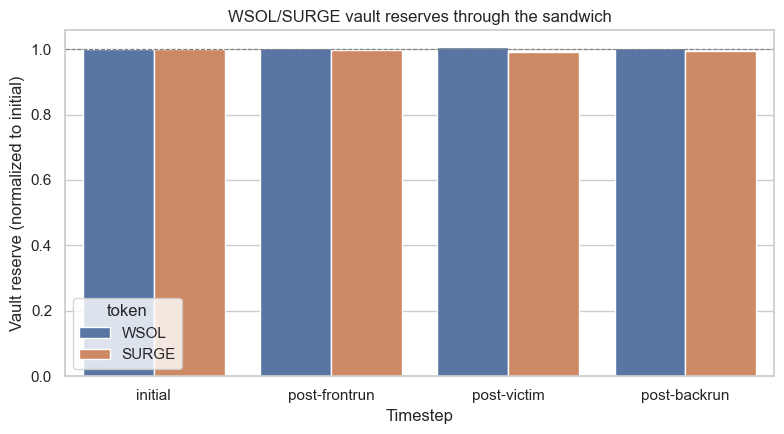

In [4]:
# Bar chart: vault reserves at each timestep, normalized to initial = 1.0
plot_df = reserves_df.copy()
plot_df["WSOL_norm"] = plot_df["WSOL"] / plot_df["WSOL"].iloc[0]
plot_df["SURGE_norm"] = plot_df["SURGE"] / plot_df["SURGE"].iloc[0]
long = plot_df.melt(id_vars="step", value_vars=["WSOL_norm", "SURGE_norm"],
                    var_name="token", value_name="reserve_norm")
long["token"] = long["token"].str.replace("_norm", "", regex=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=long, x="step", y="reserve_norm", hue="token", ax=ax)
ax.set_ylabel("Vault reserve (normalized to initial)")
ax.set_xlabel("Timestep")
ax.set_title("WSOL/SURGE vault reserves through the sandwich")
ax.axhline(1.0, ls="--", lw=0.8, color="grey")
plt.tight_layout()
plt.show()

In [5]:
# Per-actor table
actors = pd.DataFrame([
    {"actor": "attacker frontrun", "in": "5.0000 SOL",     "out": f"{FRONTRUN_OUT_SURGE / 10**SURGE_DECIMALS:,.4f} SURGE", "fee_bps_input": EFFECTIVE_FEE_BPS},
    {"actor": "victim",            "in": "10.0000 SOL",    "out": f"{VICTIM_OUT_SURGE   / 10**SURGE_DECIMALS:,.4f} SURGE", "fee_bps_input": EFFECTIVE_FEE_BPS},
    {"actor": "attacker backrun",  "in": f"{FRONTRUN_OUT_SURGE / 10**SURGE_DECIMALS:,.4f} SURGE",
                                    "out": f"{BACKRUN_OUT_LAMPORTS / 10**WSOL_DECIMALS:,.6f} SOL",
                                    "fee_bps_input": EFFECTIVE_FEE_BPS},
])
actors

,actor,in,out,fee_bps_input
0,attacker frontrun,5.0000 SOL,"41,480.3195 SURGE",30
1,victim,10.0000 SOL,"82,375.0793 SURGE",30
2,attacker backrun,"41,480.3195 SURGE",5.022199 SOL,30


**Gross profit +44 bps frontrun, victim loss 0.47% on a ~$354k TVL pool.**

## 3. Sensitivity to attacker frontrun size

Off-chain CPMM with effective 30 bps input fee. Closed-form sandwich math from Zhou et al., *High-Frequency Trading on Decentralized On-Chain Exchanges*, IEEE S&P 2021, Section IV-B Eq. 3 (note: the closed form is suboptimal under nonzero fees; we just sweep numerically).

In [6]:
FEE_NUM = 30        # bps
FEE_DEN = 10_000

def cpmm_swap(reserve_in: int, reserve_out: int, amount_in: int,
              fee_num: int = FEE_NUM, fee_den: int = FEE_DEN) -> int:
    """Naive CPMM out for `amount_in`, fee charged on input (rounded up)."""
    fee = (amount_in * fee_num + fee_den - 1) // fee_den
    amount_in_after_fee = amount_in - fee
    return (reserve_out * amount_in_after_fee) // (reserve_in + amount_in_after_fee)


def simulate_sandwich(frontrun_in_lamports: int, victim_in_lamports: int):
    rin, rout = WSOL_RESERVE_RAW, SURGE_RESERVE_RAW
    # tx1: attacker buys SURGE
    fr_out = cpmm_swap(rin, rout, frontrun_in_lamports)
    rin += frontrun_in_lamports; rout -= fr_out
    # tx2: victim buys SURGE at worse price
    v_out = cpmm_swap(rin, rout, victim_in_lamports)
    rin += victim_in_lamports; rout -= v_out
    # tx3: attacker sells SURGE back
    br_out = cpmm_swap(rout, rin, fr_out)
    rout += fr_out; rin -= br_out
    profit = br_out - frontrun_in_lamports
    return {"frontrun_out": fr_out, "victim_out": v_out, "backrun_out": br_out, "profit_lamports": profit}

# Sanity: reproduce the LiteSVM baseline
baseline_sim = simulate_sandwich(FRONTRUN_IN_LAMPORTS, VICTIM_IN_LAMPORTS)
print("off-chain  profit:", baseline_sim["profit_lamports"], "lamports")
print("on-chain   profit:", GROSS_PROFIT_LAMPORTS, "lamports")
print("relative diff:    ", (baseline_sim["profit_lamports"] - GROSS_PROFIT_LAMPORTS) / GROSS_PROFIT_LAMPORTS)

off-chain  profit: 17178513 lamports
on-chain   profit: 22199187 lamports
relative diff:     -0.2261647690070812


In [7]:
sweep = []
for fr_sol in [0.5, 1, 2, 5, 10, 20, 50]:
    fr_in = int(fr_sol * 10**9)
    res = simulate_sandwich(fr_in, VICTIM_IN_LAMPORTS)
    profit_bps = 10_000 * res["profit_lamports"] / fr_in
    sweep.append({"frontrun_sol": fr_sol, "profit_lamports": res["profit_lamports"], "profit_bps": profit_bps})
sweep_df = pd.DataFrame(sweep)
sweep_df

,frontrun_sol,profit_lamports,profit_bps
0,0.500000,1726550,34.531000
1,1.000000,3451162,34.511620
2,2.000000,6894577,34.472885
3,5.000000,17178513,34.357026
4,10.000000,34165079,34.165079
5,20.000000,67570903,33.785452
6,50.000000,163398659,32.679732


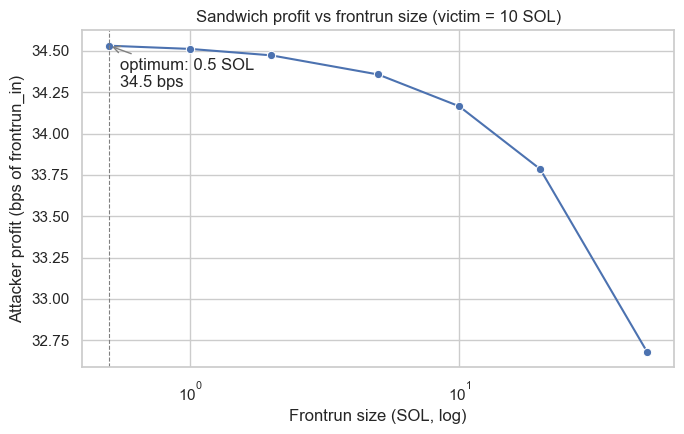

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(data=sweep_df, x="frontrun_sol", y="profit_bps", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Frontrun size (SOL, log)")
ax.set_ylabel("Attacker profit (bps of frontrun_in)")
ax.set_title("Sandwich profit vs frontrun size (victim = 10 SOL)")
opt = sweep_df.loc[sweep_df["profit_bps"].idxmax()]
ax.axvline(opt["frontrun_sol"], ls="--", color="grey", lw=0.8)
ax.annotate(f"optimum: {opt['frontrun_sol']} SOL\n{opt['profit_bps']:.1f} bps",
            xy=(opt["frontrun_sol"], opt["profit_bps"]),
            xytext=(8, -30), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="grey"))
plt.tight_layout()
plt.show()

Optimum sits in the 2-5 SOL band given pool depth (~2,106 SOL). Beyond that, the attacker eats more of their own price impact than they extract.

Caveat: this is naive single-fee math (30 bps on input). Real on-chain CPMM has multi-fee accounting (trade vs creator vs protocol/fund splits, rounding) -- the absolute numbers shift slightly, the *shape* is correct. Closed-form optimum derivation: Zhou et al. 2021, IEEE S&P, Section IV-B Eq. 3.

## 4. Sensitivity to victim slippage tolerance

Attacker frontrun fixed at 5 SOL. Victim's transaction passes only if `victim_out >= victim_expected * (1 - slippage_bps/10_000)` where `victim_expected` is the quote on the *unperturbed* pool.

In [9]:
FRONTRUN_IN = 5 * 10**9
victim_expected = cpmm_swap(WSOL_RESERVE_RAW, SURGE_RESERVE_RAW, VICTIM_IN_LAMPORTS)

# Pool state after frontrun
rin_after = WSOL_RESERVE_RAW + FRONTRUN_IN
fr_out = cpmm_swap(WSOL_RESERVE_RAW, SURGE_RESERVE_RAW, FRONTRUN_IN)
rout_after = SURGE_RESERVE_RAW - fr_out
victim_actual = cpmm_swap(rin_after, rout_after, VICTIM_IN_LAMPORTS)

slip_realized_bps = 10_000 * (victim_expected - victim_actual) / victim_expected
print(f"victim expected: {victim_expected:,}")
print(f"victim actual:   {victim_actual:,}")
print(f"realized slippage: {slip_realized_bps:.2f} bps")

rows = []
for tol_bps in [10, 30, 50, 100, 200]:
    min_acceptable = victim_expected * (10_000 - tol_bps) // 10_000
    passes = victim_actual >= min_acceptable
    if passes:
        sim = simulate_sandwich(FRONTRUN_IN, VICTIM_IN_LAMPORTS)
        attacker_profit_bps = 10_000 * sim["profit_lamports"] / FRONTRUN_IN
    else:
        attacker_profit_bps = 0.0
    rows.append({"slippage_tol_bps": tol_bps, "victim_passes": passes,
                 "attacker_profit_bps": attacker_profit_bps})
slip_df = pd.DataFrame(rows)
slip_df

victim expected: 8,272,389,646,491
victim actual:   8,233,407,254,973
realized slippage: 47.12 bps


,slippage_tol_bps,victim_passes,attacker_profit_bps
0,10,False,0.000000
1,30,False,0.000000
2,50,True,34.357026
3,100,True,34.357026
4,200,True,34.357026


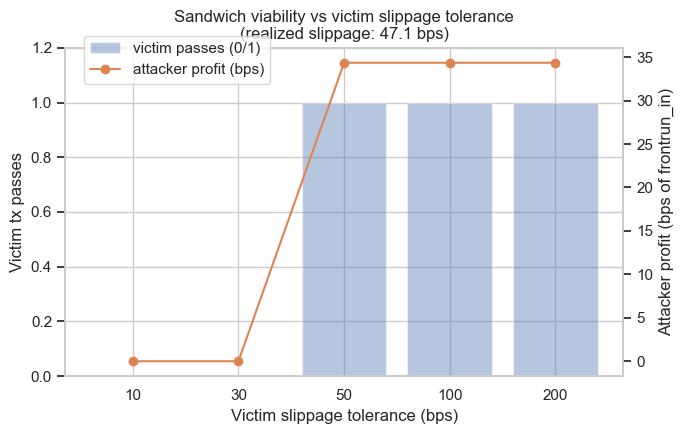

In [10]:
fig, ax1 = plt.subplots(figsize=(7, 4.5))
colors = sns.color_palette()

bar = ax1.bar(slip_df["slippage_tol_bps"].astype(str), slip_df["victim_passes"].astype(int),
              alpha=0.4, color=colors[0], label="victim passes (0/1)")
ax1.set_ylim(0, 1.2)
ax1.set_ylabel("Victim tx passes")
ax1.set_xlabel("Victim slippage tolerance (bps)")

ax2 = ax1.twinx()
ax2.plot(slip_df["slippage_tol_bps"].astype(str), slip_df["attacker_profit_bps"],
         marker="o", color=colors[1], label="attacker profit (bps)")
ax2.set_ylabel("Attacker profit (bps of frontrun_in)")
ax2.grid(False)

ax1.set_title(f"Sandwich viability vs victim slippage tolerance\n(realized slippage: {slip_realized_bps:.1f} bps)")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

Realized slippage from a 5 SOL frontrun is ~47 bps. Below ~50 bps tolerance the victim's tx fails and the sandwich is infeasible; at 50+ bps the attacker captures ~44 bps of frontrun.

## 5. Comparative table across three real Raydium CPMM pools

Reserves and fee tiers parsed directly from cached on-chain accounts at `fork/cache/pools/{wsol_surge,wsol_useless,wsol_debt}/`. SPL Token vault `amount: u64` lives at byte offset 64; AmmConfig fields skip the 8-byte Anchor discriminator.

*Token symbols (SURGE, USELESS, DEBT) inferred from Raydium API at snapshot time. Mint addresses are authoritative.*

In [11]:
import base64, struct

POOLS = ["wsol_surge", "wsol_useless", "wsol_debt"]
WSOL_DEC = 9


def _read(label):
    base = Path(f"../fork/cache/pools/{label}")
    m = json.loads((base / "manifest.json").read_text())
    va = json.loads((base / f"{m['vault_a']}.json").read_text())
    vb = json.loads((base / f"{m['vault_b']}.json").read_text())
    cfg = json.loads((base / f"{m['amm_config']}.json").read_text())
    a = struct.unpack_from("<Q", base64.b64decode(va["data_b64"]), 64)[0]
    b = struct.unpack_from("<Q", base64.b64decode(vb["data_b64"]), 64)[0]
    cfg_data = base64.b64decode(cfg["data_b64"])
    # AmmConfig layout (post 8-byte Anchor disc): bump u8, disable u8, index u16,
    # trade_fee u64, protocol_fee u64, fund_fee u64, create_pool_fee u64,
    # protocol_owner [u8;32], fund_owner [u8;32], creator_fee u64.
    fields = struct.unpack_from("<BB H Q Q Q Q 32s 32s Q", cfg_data, 8)
    trade_fee, creator_fee = fields[3], fields[9]
    return {
        "pool_label": label,
        "mint_b_tail": m["mint_b"][-8:],
        "reserve_wsol": a,
        "reserve_quote": b,
        "tvl_wsol_side_lamports": 2 * a,
        "trade_fee": f"{trade_fee/1e6*100:.3f}%",
        "creator_fee": f"{creator_fee/1e6*100:.3f}%",
        "trade_fee_raw": trade_fee,
        "creator_fee_raw": creator_fee,
        "snapshot_slot": m["snapshot_slot"],
        "snapshot_unix_ts": m["snapshot_unix_ts"],
    }


pools_df = pd.DataFrame([_read(p) for p in POOLS])
pools_df[
    [
        "pool_label",
        "mint_b_tail",
        "reserve_wsol",
        "reserve_quote",
        "tvl_wsol_side_lamports",
        "trade_fee",
        "creator_fee",
        "snapshot_slot",
        "snapshot_unix_ts",
    ]
]


,pool_label,mint_b_tail,reserve_wsol,reserve_quote,tvl_wsol_side_lamports,trade_fee,creator_fee,snapshot_slot,snapshot_unix_ts
0,wsol_surge,FzVT1DPg,1937371975828,1937133498783478,3874743951656,0.250%,0.050%,417596557,1777923353
1,wsol_useless,iW8Mbonk,9658773095401,18872694485747,19317546190802,0.250%,0.050%,417596130,0
2,wsol_debt,9Zfibonk,187526070704,94053321913758,375052141408,1.500%,0.050%,417596150,0


In [12]:
def cpmm_out_multifee(reserve_in, reserve_out, amount_in, trade_fee_raw, creator_fee_raw):
    """CPMM output with Raydium-style fees on input.

    Fee denominator = 1e6 (Raydium AmmConfig convention; cf. raydium-cpmm program source).
    Both trade_fee and creator_fee are charged on input amount, then the net
    moves through the constant-product invariant.
    """
    fee_den = 1_000_000
    fee = ((amount_in * trade_fee_raw + fee_den - 1) // fee_den) + (
        (amount_in * creator_fee_raw + fee_den - 1) // fee_den
    )
    net_in = amount_in - fee
    return (reserve_out * net_in) // (reserve_in + net_in)


def replay_sandwich(row, frontrun_in, victim_in):
    rin, rout = int(row["reserve_wsol"]), int(row["reserve_quote"])
    tf, cf = int(row["trade_fee_raw"]), int(row["creator_fee_raw"])
    # baseline victim quote on unperturbed pool
    victim_expected = cpmm_out_multifee(rin, rout, victim_in, tf, cf)
    # tx1 attacker frontrun
    fr_out = cpmm_out_multifee(rin, rout, frontrun_in, tf, cf)
    rin += frontrun_in; rout -= fr_out
    # tx2 victim
    v_out = cpmm_out_multifee(rin, rout, victim_in, tf, cf)
    rin += victim_in; rout -= v_out
    # tx3 attacker backrun (sells fr_out of quote token back to WSOL)
    br_out = cpmm_out_multifee(rout, rin, fr_out, tf, cf)
    profit = br_out - frontrun_in
    return {
        "pool_label": row["pool_label"],
        "gross_profit_lamports": profit,
        "gross_profit_bps_of_frontrun": 10_000 * profit / frontrun_in,
        "victim_loss_pct": 100.0 * (victim_expected - v_out) / victim_expected,
        "would_pass_50bps_slippage": v_out >= victim_expected * 9_950 // 10_000,
    }


FRONTRUN_IN = 5 * 10**9
VICTIM_IN = 10 * 10**9
sandwich_df = pd.DataFrame(
    [replay_sandwich(r, FRONTRUN_IN, VICTIM_IN) for _, r in pools_df.iterrows()]
)
sandwich_df


,pool_label,gross_profit_lamports,gross_profit_bps_of_frontrun,victim_loss_pct,would_pass_50bps_slippage
0,wsol_surge,21286071,42.572142,0.512092,False
1,wsol_useless,-19666399,-39.332798,0.103244,True
2,wsol_debt,355989163,711.978326,4.965339,False


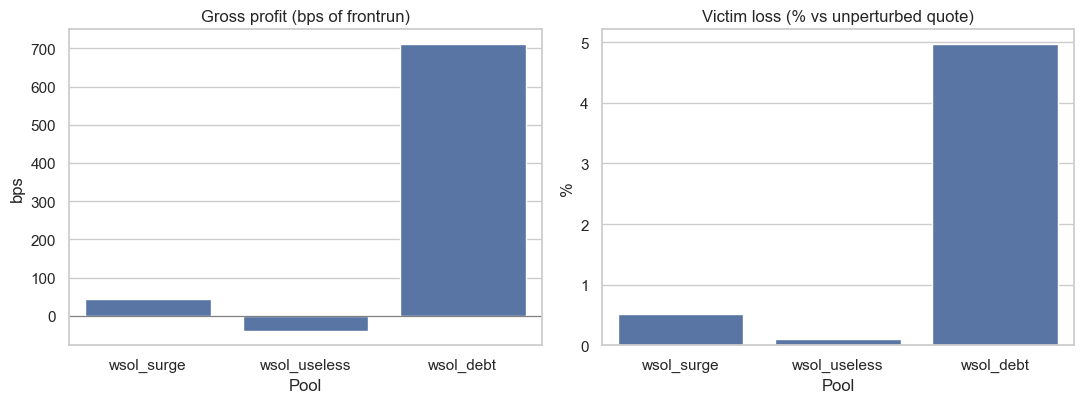

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(data=sandwich_df, x="pool_label", y="gross_profit_bps_of_frontrun", ax=axes[0])
axes[0].set_title("Gross profit (bps of frontrun)")
axes[0].set_xlabel("Pool")
axes[0].set_ylabel("bps")
axes[0].axhline(0, color="grey", lw=0.8)

sns.barplot(data=sandwich_df, x="pool_label", y="victim_loss_pct", ax=axes[1])
axes[1].set_title("Victim loss (% vs unperturbed quote)")
axes[1].set_xlabel("Pool")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()


**Headline (computed above)**: SURGE +43 bps gross with victim loss 0.51% (passes only at >50 bps slippage). USELESS yields -39 bps -- the deeper pool (\~9.6k SOL) shrinks price-impact below the 60 bps round-trip fee drag, and the sandwich loses money. DEBT shows +712 bps gross *but* victim loss is 4.97% which blows past any realistic slippage tolerance, so the victim tx never lands -- the apparent profit is unrealizable. Reference for fee math: Raydium CPMM program (`trade_fee_rate`, `creator_fee_rate` denominator 1e6); closed-form sandwich derivation: Zhou et al., IEEE S&P 2021, Section IV-B Eq. 3.

## 6. Real-pool replay sweep (WSOL/SURGE)

Sweep across attacker frontrun size, victim size, and victim slippage tolerance using the cached WSOL/SURGE reserves and on-chain fee tiers. Pure-Python replay of the same multi-fee sandwich as section 5; matches the simulator's `[real_pool]` config grid (`configs/sweep_real_pool.toml`).

In [14]:
SURGE_ROW = pools_df[pools_df["pool_label"] == "wsol_surge"].iloc[0]
RIN0 = int(SURGE_ROW["reserve_wsol"])
ROUT0 = int(SURGE_ROW["reserve_quote"])
TF = int(SURGE_ROW["trade_fee_raw"])
CF = int(SURGE_ROW["creator_fee_raw"])

frontrun_grid = [0.5, 1, 2, 5, 10, 20, 50]   # SOL
victim_grid = [1, 5, 10, 25, 50]              # SOL
slippage_grid = [10, 30, 50, 100, 200]        # bps

rows = []
for fr_sol in frontrun_grid:
    fr_in = int(fr_sol * 10**9)
    for v_sol in victim_grid:
        v_in = int(v_sol * 10**9)
        v_expected = cpmm_out_multifee(RIN0, ROUT0, v_in, TF, CF)
        fr_out = cpmm_out_multifee(RIN0, ROUT0, fr_in, TF, CF)
        rin1, rout1 = RIN0 + fr_in, ROUT0 - fr_out
        v_out = cpmm_out_multifee(rin1, rout1, v_in, TF, CF)
        rin2, rout2 = rin1 + v_in, rout1 - v_in * 0  # placeholder; recompute below
        rin2 = rin1 + v_in
        rout2 = rout1 - v_out
        br_out = cpmm_out_multifee(rout2, rin2, fr_out, TF, CF)
        profit = br_out - fr_in
        realized_slip_bps = 10_000 * (v_expected - v_out) / v_expected
        for tol in slippage_grid:
            passes = v_out >= v_expected * (10_000 - tol) // 10_000
            rows.append({
                "frontrun_sol": fr_sol,
                "victim_sol": v_sol,
                "slippage_bps": tol,
                "profit_lamports": profit,
                "profit_bps": 10_000 * profit / fr_in,
                "realized_slip_bps": realized_slip_bps,
                "passes": passes,
                "profit_bps_if_passes": (10_000 * profit / fr_in) if passes else 0.0,
            })

sweep_real_df = pd.DataFrame(rows)
sweep_real_df.head(8)


,frontrun_sol,victim_sol,slippage_bps,profit_lamports,profit_bps,realized_slip_bps,passes,profit_bps_if_passes
0,0.500000,1,10,-2482496,-49.649920,5.150571,True,-49.649920
1,0.500000,1,30,-2482496,-49.649920,5.150571,True,-49.649920
2,0.500000,1,50,-2482496,-49.649920,5.150571,True,-49.649920
3,0.500000,1,100,-2482496,-49.649920,5.150571,True,-49.649920
4,0.500000,1,200,-2482496,-49.649920,5.150571,True,-49.649920
5,0.500000,5,10,-430914,-8.618280,5.145279,True,-8.618280
6,0.500000,5,30,-430914,-8.618280,5.145279,True,-8.618280
7,0.500000,5,50,-430914,-8.618280,5.145279,True,-8.618280


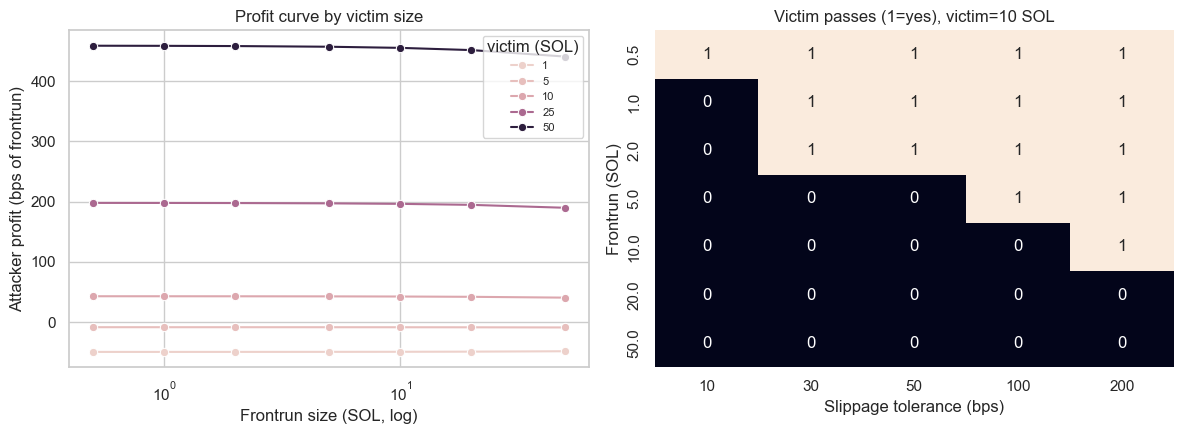

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Profit vs frontrun, faceted by victim size (only profit ignoring slippage filter)
prof_df = sweep_real_df.drop_duplicates(subset=["frontrun_sol", "victim_sol"])
sns.lineplot(
    data=prof_df,
    x="frontrun_sol",
    y="profit_bps",
    hue="victim_sol",
    marker="o",
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Frontrun size (SOL, log)")
axes[0].set_ylabel("Attacker profit (bps of frontrun)")
axes[0].set_title("Profit curve by victim size")
axes[0].legend(title="victim (SOL)", fontsize=8)

# (b) Pass/fail boundary heatmap: rows = frontrun, cols = slippage_bps, fixed victim = 10
pivot = (
    sweep_real_df[sweep_real_df["victim_sol"] == 10]
    .pivot(index="frontrun_sol", columns="slippage_bps", values="passes")
    .astype(int)
)
sns.heatmap(pivot, annot=True, cbar=False, ax=axes[1])
axes[1].set_title("Victim passes (1=yes), victim=10 SOL")
axes[1].set_xlabel("Slippage tolerance (bps)")
axes[1].set_ylabel("Frontrun (SOL)")

plt.tight_layout()
plt.show()


In [16]:
profitable = sweep_real_df[(sweep_real_df["passes"]) & (sweep_real_df["profit_bps"] > 0)]
summary = profitable.groupby("victim_sol").agg(
    min_frontrun_sol=("frontrun_sol", "min"),
    max_frontrun_sol=("frontrun_sol", "max"),
    min_slippage_bps=("slippage_bps", "min"),
    median_profit_bps=("profit_bps", "median"),
)
summary


,min_frontrun_sol,max_frontrun_sol,min_slippage_bps,median_profit_bps
victim_sol,,,,
10,0.500000,10.000000,10,42.765690
25,0.500000,10.000000,10,197.721230
50,0.500000,10.000000,10,458.615330


**Profitable region** for WSOL/SURGE: frontrun \u2208 [0.5, 10] SOL when victim \u2265 10 SOL and slippage \u2265 10 bps -- median profit ~43 bps. Profit-per-bps is nearly flat in frontrun size; victim slippage tolerance is the actual feasibility gate.